# BRFSS 2021 Heart Disease Project

## Objective

This notebook prepares the BRFSS 2021 data before EDA and modeling.

The main goals are to:

- inspect the original BRFSS metadata,
- select a smaller set of relevant variables,
- block direct target leakage,
- extract only the columns needed for the project,
- inspect missing values and CDC special codes,
- document the cleaning rules that will be used in the next step.

The target is `_MICHD`, which represents whether a respondent reported a history of myocardial infarction or coronary heart disease.

This is a **cross-sectional status-classification project**, not a future clinical diagnosis model.

## 1. Read the BRFSS Metadata

The original XPT file is large, so I first read only its metadata.  
This gives the variable names and descriptions without loading the full dataset.

In [1]:
import sys
print(sys.executable)

C:\Users\HP\Desktop\BinX-AI-ML-Internship\.venv\Scripts\python.exe


In [2]:
%pip install pyreadstat matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadstat

XPT_PATH = Path(
    r"C:\Users\HP\Downloads\LLCP2021XPT\LLCP2021.XPT"
)

print("File exists:", XPT_PATH.exists())
print("File path:", XPT_PATH)

File exists: True
File path: C:\Users\HP\Downloads\LLCP2021XPT\LLCP2021.XPT


In [4]:
_, meta = pyreadstat.read_xport(
    XPT_PATH,
    metadataonly=True,
)

print("Number of variables:", len(meta.column_names))

Number of variables: 303


In [69]:
metadata_df = pd.DataFrame({
    "variable": meta.column_names,
    "description": meta.column_labels,
})

print("Shape:", metadata_df.shape)
display(metadata_df.head(320))

Shape: (303, 2)


,variable,description
0,_STATE,STATE FIPS CODE
1,FMONTH,FILE MONTH
2,IDATE,INTERVIEW DATE
3,IMONTH,INTERVIEW MONTH
4,IDAY,INTERVIEW DAY
...,...,...
298,_VEGLT1A,CONSUME VEGETABLES 1 OR MORE TIMES PER D
299,_FRT16A,REPORTED CONSUMING FRUIT >16/DAY
300,_VEG23A,REPORTED CONSUMING VEGETABLES >23/DAY
301,_FRUITE1,FRUIT EXCLUSION FROM ANALYSES


In [6]:
METADATA_PATH = Path("../data/metadata/brfss2021_metadata.csv")

METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)

metadata_df.to_csv(
    METADATA_PATH,
    index=False,
)

print("Saved:", METADATA_PATH.resolve())

Saved: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\data\metadata\brfss2021_metadata.csv


## 2. Select the Curated Columns

The BRFSS file contains 303 variables in the metadata extracted from my local XPT file.

I reviewed the variables before loading the full data. The main filters were:

- remove survey and administrative fields,
- remove unrelated optional modules,
- remove redundant raw/derived representations,
- keep a compact set of health, demographic, lifestyle, and healthcare variables,
- exclude variables that directly create the target.

`CVDINFR4` and `CVDCRHD4` are not used because `_MICHD` is derived from them.

The extraction set contains **37 columns**:

- 1 target,
- 28 primary candidates,
- 5 sensitivity variables,
- 3 alternative representations.

These are extraction candidates, not the final model features.

In [7]:
EXTRACTION_COLUMNS = [
    "SEXVAR",
    "GENHLTH",
    "PHYSHLTH",
    "MENTHLTH",
    "PRIMINSR",
    "PERSDOC3",
    "MEDCOST1",
    "CHECKUP1",
    "EXERANY2",
    "BPHIGH6",
    "CHOLCHK3",
    "TOLDHI3",

    # Sensitivity / comorbidity candidates
    "CVDSTRK3",
    "ASTHMA3",
    "CHCCOPD3",
    "ADDEPEV3",
    "CHCKDNY2",
    "DIABETE4",
    "HAVARTH5",

    "MARITAL",
    "EMPLOY1",
    "DIFFWALK",

    # Alternative representations
    "_RFCHOL3",

    # Target
    "_MICHD",

    "_RACEGR3",
    "_AGEG5YR",
    "_AGE80",

    "_BMI5",
    "_BMI5CAT",

    "_EDUCAG",
    "_INCOMG1",

    "_SMOKER3",

    "DRNKANY5",
    "_RFBING5",
    "_RFDRHV7",

    "_FRTLT1A",
    "_VEGLT1A",
]

print("Columns selected for extraction:", len(EXTRACTION_COLUMNS))

Columns selected for extraction: 37


In [8]:
TARGET = "_MICHD"

DIRECT_LEAKAGE_COLUMNS = {
    "CVDINFR4",
    "CVDCRHD4",
}

selected_set = set(EXTRACTION_COLUMNS)

assert TARGET in selected_set, "Target is missing from extraction set."

assert selected_set.isdisjoint(DIRECT_LEAKAGE_COLUMNS), (
    "Direct target leakage detected!"
)

assert len(EXTRACTION_COLUMNS) == len(selected_set), (
    "Duplicate columns found in extraction set."
)

print("Target present:", TARGET)
print("Direct leakage check: PASSED")
print("Duplicate check: PASSED")

Target present: _MICHD
Direct leakage check: PASSED
Duplicate check: PASSED


In [9]:
available_columns = set(meta.column_names)

missing_columns = [
    col for col in EXTRACTION_COLUMNS
    if col not in available_columns
]

print("Requested columns:", len(EXTRACTION_COLUMNS))
print("Missing columns:", missing_columns)

assert not missing_columns, (
    f"Columns missing from XPT metadata: {missing_columns}"
)

print("Schema validation: PASSED")

Requested columns: 37
Missing columns: []
Schema validation: PASSED


In [10]:
curated_df, curated_meta = pyreadstat.read_xport(
    XPT_PATH,
    usecols=EXTRACTION_COLUMNS,
)
print("Curated dataset shape:", curated_df.shape)
display(curated_df.head())

Curated dataset shape: (438693, 37)


,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,PRIMINSR,PERSDOC3,MEDCOST1,CHECKUP1,EXERANY2,BPHIGH6,...,_BMI5,_BMI5CAT,_EDUCAG,_INCOMG1,_SMOKER3,DRNKANY5,_RFBING5,_RFDRHV7,_FRTLT1A,_VEGLT1A
0,2.0,5.0,20.0,10.0,3.0,1.0,2.0,2.0,2.0,3.0,...,1454.0,1.0,2.0,3.0,3.0,2.0,1.0,1.0,1.0,1.0
1,2.0,3.0,88.0,88.0,1.0,2.0,2.0,1.0,1.0,1.0,...,NaN,NaN,4.0,9.0,4.0,2.0,1.0,1.0,1.0,1.0
2,2.0,2.0,88.0,88.0,2.0,2.0,2.0,1.0,2.0,1.0,...,2829.0,3.0,2.0,2.0,4.0,2.0,1.0,1.0,1.0,2.0
3,2.0,2.0,88.0,10.0,2.0,1.0,2.0,1.0,1.0,1.0,...,3347.0,4.0,2.0,5.0,4.0,1.0,2.0,1.0,1.0,1.0
4,1.0,5.0,30.0,88.0,3.0,1.0,2.0,1.0,1.0,4.0,...,2873.0,3.0,1.0,2.0,4.0,2.0,1.0,1.0,1.0,1.0


## 3. Data Quality Audit

Before cleaning the data, I need to understand how missing values are represented.

BRFSS does not use one universal missing-value code. For example:

- `PHYSHLTH = 88` means **zero days**, not missing,
- `PRIMINSR = 88` means **no health coverage**, which is a valid category,
- `CHECKUP1 = 8` means **never**, which is also valid,
- codes such as `7`, `9`, `77`, and `99` usually represent unknown or refused responses, depending on the variable.

Because of this, I will not apply one global replacement rule to every column.

### 3.1 Target Check

In [11]:
target_counts = curated_df["_MICHD"].value_counts(dropna=False).sort_index()
display(target_counts)

valid_target_rows = curated_df["_MICHD"].notna().sum()
positive_rows = (curated_df["_MICHD"] == 1).sum()
negative_rows = (curated_df["_MICHD"] == 2).sum()
target_missing = curated_df["_MICHD"].isna().sum()

print("Valid target rows:", f"{valid_target_rows:,}")
print("Positive rows:", f"{positive_rows:,}")
print("Negative rows:", f"{negative_rows:,}")
print("Target-missing rows:", f"{target_missing:,}")
print("Positive prevalence:", f"{positive_rows / valid_target_rows * 100:.2f}%")

assert set(curated_df["_MICHD"].dropna().unique()).issubset({1.0, 2.0})
assert (positive_rows, negative_rows, target_missing) == (35323, 398735, 4635)

print("Target check: PASSED")

_MICHD
1.0     35323
2.0    398735
NaN      4635
Name: count, dtype: int64

Valid target rows: 434,058
Positive rows: 35,323
Negative rows: 398,735
Target-missing rows: 4,635
Positive prevalence: 8.14%
Target check: PASSED


The target is strongly imbalanced: only about 8% of rows with a known target are positive.

The 4,635 rows with a missing target will be removed in the cleaning phase.  
They will **not** be imputed or converted to the negative class.

### 3.2 Raw Missing Values and Special Codes

In [12]:
SPECIAL_MISSING_CODES = {
    "GENHLTH": [
        7,
        9
    ],
    "PHYSHLTH": [
        77,
        99
    ],
    "MENTHLTH": [
        77,
        99
    ],
    "PRIMINSR": [
        77,
        99
    ],
    "PERSDOC3": [
        7,
        9
    ],
    "MEDCOST1": [
        7,
        9
    ],
    "CHECKUP1": [
        7,
        9
    ],
    "EXERANY2": [
        7,
        9
    ],
    "BPHIGH6": [
        7,
        9
    ],
    "CHOLCHK3": [
        7,
        9
    ],
    "TOLDHI3": [
        7,
        9
    ],
    "CVDSTRK3": [
        7,
        9
    ],
    "ASTHMA3": [
        7,
        9
    ],
    "CHCCOPD3": [
        7,
        9
    ],
    "ADDEPEV3": [
        7,
        9
    ],
    "CHCKDNY2": [
        7,
        9
    ],
    "DIABETE4": [
        7,
        9
    ],
    "HAVARTH5": [
        7,
        9
    ],
    "MARITAL": [
        9
    ],
    "EMPLOY1": [
        9
    ],
    "DIFFWALK": [
        7,
        9
    ],
    "_RFCHOL3": [
        9
    ],
    "_RACEGR3": [
        9
    ],
    "_AGEG5YR": [
        14
    ],
    "_EDUCAG": [
        9
    ],
    "_INCOMG1": [
        9
    ],
    "_SMOKER3": [
        9
    ],
    "DRNKANY5": [
        7,
        9
    ],
    "_RFBING5": [
        9
    ],
    "_RFDRHV7": [
        9
    ],
    "_FRTLT1A": [
        9
    ],
    "_VEGLT1A": [
        9
    ]
}

quality_summary = pd.DataFrame({
    "raw_missing_count": curated_df.isna().sum(),
    "raw_missing_pct": (curated_df.isna().mean() * 100).round(2),
    "unique_values": curated_df.nunique(dropna=True),
})

special_missing_counts = {}

for column, codes in SPECIAL_MISSING_CODES.items():
    special_missing_counts[column] = curated_df[column].isin(codes).sum()

quality_summary["special_code_count"] = pd.Series(special_missing_counts).reindex(
    quality_summary.index,
    fill_value=0,
)

quality_summary["effective_missing_count"] = (
    quality_summary["raw_missing_count"]
    + quality_summary["special_code_count"]
)

quality_summary["effective_missing_pct"] = (
    quality_summary["effective_missing_count"]
    / len(curated_df)
    * 100
).round(2)

quality_summary = quality_summary.sort_values(
    "effective_missing_pct",
    ascending=False,
)

display(quality_summary.head(15))

,raw_missing_count,raw_missing_pct,unique_values,special_code_count,effective_missing_count,effective_missing_pct
_INCOMG1,0,0.00,8,94413,94413,21.52
_RFCHOL3,61151,13.94,3,3138,64289,14.65
TOLDHI3,60836,13.87,4,3144,63980,14.58
_VEGLT1A,0,0.00,3,60127,60127,13.71
_FRTLT1A,0,0.00,3,51087,51087,11.65
_BMI5CAT,46852,10.68,4,0,46852,10.68
_BMI5,46852,10.68,3887,0,46852,10.68
_RFBING5,0,0.00,3,35322,35322,8.05
_RFDRHV7,0,0.00,3,34993,34993,7.98
DRNKANY5,0,0.00,4,30589,30589,6.97


The effective missing rate is more useful than `isna()` alone because several BRFSS variables store unknown/refused responses as numeric codes.

A high missing rate is **not** enough by itself to drop a feature.  
For example, income has substantial missingness, but deleting every respondent with missing income would remove too much data. Its value will be tested later with cross-validation.

### 3.3 Cholesterol Skip Logic

`TOLDHI3` is a follow-up question about high cholesterol. According to the BRFSS questionnaire logic, it is only usable when the respondent has had cholesterol checked.

I check this relationship directly instead of treating every blank as random missingness.

In [13]:
cholesterol_eligible = curated_df["CHOLCHK3"].isin([2, 3, 4, 5, 6, 8])

toldhi_inside_skip = (
    (~cholesterol_eligible)
    & curated_df["TOLDHI3"].notna()
).sum()

toldhi_missing_when_eligible = (
    cholesterol_eligible
    & curated_df["TOLDHI3"].isna()
).sum()

rfchol_expected_missing = ~cholesterol_eligible
rfchol_actual_missing = curated_df["_RFCHOL3"].isna()

rfchol_mismatches = (
    rfchol_expected_missing != rfchol_actual_missing
).sum()

print("Rows not eligible for TOLDHI3:", f"{(~cholesterol_eligible).sum():,}")
print("TOLDHI3 values found inside skip states:", f"{toldhi_inside_skip:,}")
print("TOLDHI3 missing while eligible:", f"{toldhi_missing_when_eligible:,}")
print("_RFCHOL3 structural mismatches:", f"{rfchol_mismatches:,}")

assert rfchol_mismatches == 0

print("\nPhase 4 rule:")
print("Use TOLDHI3 only when CHOLCHK3 is 2, 3, 4, 5, 6, or 8.")

Rows not eligible for TOLDHI3: 61,151
TOLDHI3 values found inside skip states: 317
TOLDHI3 missing while eligible: 2
_RFCHOL3 structural mismatches: 0

Phase 4 rule:
Use TOLDHI3 only when CHOLCHK3 is 2, 3, 4, 5, 6, or 8.


The local file contains a small number of `TOLDHI3` values in rows where the upstream cholesterol question indicates a skip.

I will not use those values as valid evidence. In the cleaning phase, `TOLDHI3` will only be kept for respondents who are eligible for that follow-up question.

`_RFCHOL3` remains an alternative representation rather than an additional feature to use together with `CHOLCHK3` and `TOLDHI3`.

### 3.4 BMI and Age Representations

In [14]:
# _BMI5 stores BMI with two implied decimal places.
bmi = curated_df["_BMI5"] / 100

print("BMI missing rows:", f"{bmi.isna().sum():,}")
print("BMI minimum:", bmi.min())
print("BMI maximum:", bmi.max())

assert bmi.dropna().between(12, 99.99).all()

expected_bmi_category = pd.cut(
    bmi,
    bins=[0, 18.5, 25, 30, np.inf],
    labels=[1, 2, 3, 4],
    right=False,
)

bmi_rows = curated_df["_BMI5"].notna()

bmi_category_mismatches = (
    expected_bmi_category[bmi_rows].astype(float)
    != curated_df.loc[bmi_rows, "_BMI5CAT"]
).sum()

print("BMI category mismatches:", bmi_category_mismatches)
assert bmi_category_mismatches == 0

print("\n_AGEG5YR unknown/refused/missing:",
      f"{(curated_df['_AGEG5YR'] == 14).sum():,}")
print("_AGE80 missing:", f"{curated_df['_AGE80'].isna().sum():,}")
print("_AGE80 range:",
      curated_df["_AGE80"].min(),
      "to",
      curated_df["_AGE80"].max())

BMI missing rows: 46,852
BMI minimum: 12.0
BMI maximum: 99.33
BMI category mismatches: 0

_AGEG5YR unknown/refused/missing: 9,607
_AGE80 missing: 0
_AGE80 range: 18.0 to 80.0


`_BMI5` will be the main BMI representation because it keeps more information. `_BMI5CAT` will be kept only as an alternative for later comparison.

For age, `_AGEG5YR` remains the primary representation. `_AGE80` is useful as an alternative, but it is a CDC calculated/imputed age variable and values above 80 are capped at 80.

### 3.5 Phase 3 Final Check

At this point I only want to confirm that the extracted data is still intact and that the known direct leakage variables are not present.

In [15]:
assert curated_df.shape == (438693, 37)
assert TARGET in curated_df.columns
assert set(curated_df.columns).isdisjoint(DIRECT_LEAKAGE_COLUMNS)

print("Dataset shape:", curated_df.shape)
print("Direct leakage columns present: No")
print("Additional feature drops in Phase 3: 0")
print("Phase 3 checks: PASSED")

Dataset shape: (438693, 37)
Direct leakage columns present: No
Additional feature drops in Phase 3: 0
Phase 3 checks: PASSED


## Phase 3 Summary

The 37-column subset is now understood well enough to clean safely.

Main decisions:

- `_MICHD` is the target; rows without a known target will be removed.
- `CVDINFR4` and `CVDCRHD4` remain excluded because they directly define `_MICHD`.
- missing-value handling must be column-specific.
- `PHYSHLTH = 88` and `MENTHLTH = 88` mean zero days.
- valid categories such as `PRIMINSR = 88` and `CHECKUP1 = 8` must be preserved.
- `TOLDHI3` must follow the cholesterol-question skip logic.
- `_BMI5` needs to be divided by 100.
- no feature is dropped only because it has missing values.

The next step is deterministic cleaning. Learned imputation will come later inside the modeling pipeline.

## 4. Deterministic Cleaning

This phase applies only cleaning rules that come directly from the BRFSS coding scheme.

I am **not** doing model-dependent preprocessing here. In particular:

- no learned imputation,
- no scaling,
- no one-hot encoding,
- no class balancing,
- no train/test split.

Those steps belong later inside the Scikit-learn pipeline.

The goal here is to create one clean, reproducible dataset with the original feature information preserved.

### 4.1 Clean the Target

In [16]:
clean_df = curated_df.copy()

starting_rows = len(clean_df)
target_missing_rows = clean_df["_MICHD"].isna().sum()

clean_df = clean_df[
    clean_df["_MICHD"].isin([1, 2])
].copy()

clean_df["HeartDisease"] = clean_df["_MICHD"].map({
    1: 1,
    2: 0,
}).astype("int8")

clean_df = clean_df.drop(columns="_MICHD")
clean_df = clean_df.reset_index(drop=True)

print("Starting rows:", f"{starting_rows:,}")
print("Target-missing rows removed:", f"{target_missing_rows:,}")
print("Rows after target cleaning:", f"{len(clean_df):,}")
print()
display(clean_df["HeartDisease"].value_counts().sort_index())

Starting rows: 438,693
Target-missing rows removed: 4,635
Rows after target cleaning: 434,058



HeartDisease
0    398735
1     35323
Name: count, dtype: int64

Only rows with a known target are removed.

I do not drop rows because another feature is missing. Feature missingness will be handled later inside the training pipeline so that preprocessing is learned from the training data only.

### 4.2 Apply the Cholesterol Skip Rule

In [17]:
cholesterol_eligible = clean_df["CHOLCHK3"].isin(
    [2, 3, 4, 5, 6, 8]
)

toldhi_values_cleared = (
    (~cholesterol_eligible)
    & clean_df["TOLDHI3"].notna()
).sum()

clean_df.loc[
    ~cholesterol_eligible,
    "TOLDHI3"
] = np.nan

print(
    "TOLDHI3 values cleared because the follow-up "
    "question was not applicable:",
    f"{toldhi_values_cleared:,}",
)

TOLDHI3 values cleared because the follow-up question was not applicable: 315


`TOLDHI3` is only meaningful when the respondent was eligible for the cholesterol follow-up question.

This rule is applied before the general special-code cleanup so that questionnaire skip logic is handled explicitly rather than treated as ordinary random missingness.

### 4.3 Convert Unknown / Refused Codes to Missing

In [18]:
special_code_changes = []

for column, codes in SPECIAL_MISSING_CODES.items():
    if column not in clean_df.columns:
        continue

    count = clean_df[column].isin(codes).sum()

    special_code_changes.append({
        "variable": column,
        "values_changed": int(count),
    })

    clean_df[column] = clean_df[column].replace(
        codes,
        np.nan,
    )

special_code_changes = pd.DataFrame(
    special_code_changes
).sort_values(
    "values_changed",
    ascending=False,
)

display(special_code_changes.head(15))

,variable,values_changed
25,_INCOMG1,92688
31,_VEGLT1A,58990
30,_FRTLT1A,50164
28,_RFBING5,34708
29,_RFDRHV7,34386
27,DRNKANY5,30036
9,CHOLCHK3,29036
26,_SMOKER3,24497
3,PRIMINSR,16876
22,_RACEGR3,10587


The replacement is column-specific.

This is important because some codes that look unusual are still valid responses. For example:

- `PRIMINSR = 88` means no health coverage,
- `CHECKUP1 = 8` means never had a routine checkup,
- the pregnancy-only and borderline categories in blood pressure and diabetes are kept.

Those values are not converted to missing.

### 4.4 Fix Zero-Day Codes and BMI Units

In [19]:
clean_df["PHYSHLTH"] = clean_df["PHYSHLTH"].replace(
    88,
    0,
)

clean_df["MENTHLTH"] = clean_df["MENTHLTH"].replace(
    88,
    0,
)

clean_df["_BMI5"] = clean_df["_BMI5"] / 100

print("PHYSHLTH range:",
      clean_df["PHYSHLTH"].min(),
      "to",
      clean_df["PHYSHLTH"].max())

print("MENTHLTH range:",
      clean_df["MENTHLTH"].min(),
      "to",
      clean_df["MENTHLTH"].max())

print("BMI range:",
      clean_df["_BMI5"].min(),
      "to",
      clean_df["_BMI5"].max())

PHYSHLTH range: 0.0 to 30.0
MENTHLTH range: 0.0 to 30.0
BMI range: 12.0 to 99.33


### 4.5 Keep Feature Roles Explicit

In [20]:
PRIMARY_FEATURES = [
    "SEXVAR",
    "GENHLTH",
    "PHYSHLTH",
    "MENTHLTH",
    "PRIMINSR",
    "PERSDOC3",
    "MEDCOST1",
    "CHECKUP1",
    "EXERANY2",
    "BPHIGH6",
    "CHOLCHK3",
    "TOLDHI3",
    "CHCCOPD3",
    "CHCKDNY2",
    "DIABETE4",
    "MARITAL",
    "EMPLOY1",
    "_RACEGR3",
    "_AGEG5YR",
    "_BMI5",
    "_EDUCAG",
    "_INCOMG1",
    "_SMOKER3",
    "DRNKANY5",
    "_RFBING5",
    "_RFDRHV7",
    "_FRTLT1A",
    "_VEGLT1A",
]

SENSITIVITY_FEATURES = [
    "CVDSTRK3",
    "ASTHMA3",
    "ADDEPEV3",
    "HAVARTH5",
    "DIFFWALK",
]

ALTERNATIVE_FEATURES = [
    "_RFCHOL3",
    "_AGE80",
    "_BMI5CAT",
]

print("Primary features:", len(PRIMARY_FEATURES))
print("Sensitivity features:", len(SENSITIVITY_FEATURES))
print("Alternative representations:", len(ALTERNATIVE_FEATURES))

Primary features: 28
Sensitivity features: 5
Alternative representations: 3


These groups are kept separate on purpose.

The primary list is the main candidate set.  
The sensitivity variables will later test how much performance changes when more disease-adjacent or functional-status information is added.  
The alternative variables are different representations of information already present in the primary set and should not be stacked together by default.

### 4.6 Validate the Cleaned Dataset

In [21]:
# Expected row and target counts
assert clean_df.shape == (434058, 37)

target_counts = clean_df["HeartDisease"].value_counts()

assert target_counts[1] == 35323
assert target_counts[0] == 398735
assert clean_df["HeartDisease"].isna().sum() == 0

# Direct target leakage must still be absent
assert set(clean_df.columns).isdisjoint(
    DIRECT_LEAKAGE_COLUMNS
)

# Special missing codes should no longer appear
for column, codes in SPECIAL_MISSING_CODES.items():
    if column in clean_df.columns:
        assert not clean_df[column].isin(codes).any(), (
            f"Special missing code still present in {column}"
        )

# Numeric ranges after cleaning
assert clean_df["PHYSHLTH"].dropna().between(
    0, 30
).all()

assert clean_df["MENTHLTH"].dropna().between(
    0, 30
).all()

assert clean_df["_BMI5"].dropna().between(
    12, 99.99
).all()

assert clean_df["_AGE80"].dropna().between(
    18, 80
).all()

# TOLDHI3 must be missing whenever the follow-up is not applicable
clean_cholesterol_eligible = clean_df["CHOLCHK3"].isin(
    [2, 3, 4, 5, 6, 8]
)

assert clean_df.loc[
    ~clean_cholesterol_eligible,
    "TOLDHI3"
].isna().all()

# Feature-role lists must cover all 36 predictors exactly once
all_candidate_features = (
    PRIMARY_FEATURES
    + SENSITIVITY_FEATURES
    + ALTERNATIVE_FEATURES
)

assert len(all_candidate_features) == 36
assert len(set(all_candidate_features)) == 36
assert set(all_candidate_features) == (
    set(clean_df.columns) - {"HeartDisease"}
)

print("Cleaned shape:", clean_df.shape)
print("Direct leakage check: PASSED")
print("Special-code check: PASSED")
print("Numeric-range checks: PASSED")
print("Cholesterol skip-rule check: PASSED")
print("Feature-role check: PASSED")

Cleaned shape: (434058, 37)
Direct leakage check: PASSED
Special-code check: PASSED
Numeric-range checks: PASSED
Cholesterol skip-rule check: PASSED
Feature-role check: PASSED


### 4.7 Missingness After Cleaning

In [22]:
clean_missing_summary = pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_pct": (
        clean_df.isna().mean() * 100
    ).round(2),
})

clean_missing_summary = clean_missing_summary.sort_values(
    "missing_pct",
    ascending=False,
)

display(clean_missing_summary.head(15))

,missing_count,missing_pct
_INCOMG1,92688,21.35
TOLDHI3,63134,14.55
_RFCHOL3,63134,14.55
_VEGLT1A,58990,13.59
_FRTLT1A,50164,11.56
_BMI5,46034,10.61
_BMI5CAT,46034,10.61
_RFBING5,34708,8.00
_RFDRHV7,34386,7.92
DRNKANY5,30036,6.92


Missing values are intentionally still present.

That is expected. Phase 4 removes invalid/special codes, but it does not learn replacement values from the full dataset.

Any imputation used for modeling will be fitted **inside the training pipeline**, which avoids leakage from the future test set.

### 4.8 Save the Clean Dataset

In [23]:
CLEAN_DATA_PATH = Path(
    "../data/processed/brfss2021_clean.csv.gz"
)

CLEAN_DATA_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

clean_df.to_csv(
    CLEAN_DATA_PATH,
    index=False,
    compression="gzip",
)

assert CLEAN_DATA_PATH.exists()
assert CLEAN_DATA_PATH.stat().st_size > 0

print("Saved:", CLEAN_DATA_PATH.resolve())
print("Rows:", f"{len(clean_df):,}")
print("Columns:", clean_df.shape[1])

Saved: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\data\processed\brfss2021_clean.csv.gz
Rows: 434,058
Columns: 37


### 4.9 Phase 4 Final Check

In [24]:
assert clean_df.shape == (434058, 37)
assert clean_df["HeartDisease"].value_counts().to_dict() == {
    0: 398735,
    1: 35323,
}
assert set(clean_df.columns).isdisjoint(
    DIRECT_LEAKAGE_COLUMNS
)

print("Phase 4: PASSED")
print("Processed dataset:", CLEAN_DATA_PATH.resolve())

Phase 4: PASSED
Processed dataset: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\data\processed\brfss2021_clean.csv.gz


## Phase 4 Summary

The dataset is now cleaned at the semantic/codebook level and ready for EDA.

What changed:

- 4,635 rows with an unknown target were removed.
- `_MICHD` was converted to the binary `HeartDisease` target.
- unknown/refused special codes were converted to missing values using column-specific rules.
- cholesterol follow-up values outside the valid questionnaire path were cleared.
- `PHYSHLTH = 88` and `MENTHLTH = 88` became zero days.
- `_BMI5` was converted to normal BMI units.
- no rows were dropped because a predictor was missing.
- no imputation, scaling, encoding, balancing, train/test split, or model fitting was performed.

The processed file is:

`data/processed/brfss2021_clean.csv.gz`

The next phase is **Phase 5: EDA and statistical analysis**.

## 5. Exploratory Data Analysis

Before comparing features with the target, I create the train/test split.

This keeps the test set separate from target-guided analysis and later model selection.  
All EDA that uses `HeartDisease` is performed on the **training set only**.

The test set is frozen and will not be used for model performance until the final evaluation phase.

### 5.1 Create and Freeze the Holdout Set

In [25]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

train_df, test_df = train_test_split(
    clean_df,
    test_size=TEST_SIZE,
    stratify=clean_df["HeartDisease"],
    random_state=RANDOM_STATE,
)

train_df = train_df.copy()
test_df = test_df.copy()

assert set(train_df.index).isdisjoint(test_df.index)
assert len(train_df) + len(test_df) == len(clean_df)

print("Training rows:", f"{len(train_df):,}")
print("Frozen test rows:", f"{len(test_df):,}")
print(
    "Training positive rate:",
    f"{train_df['HeartDisease'].mean() * 100:.2f}%"
)

print("\nTest set is frozen. No model metrics will be calculated on it yet.")

Training rows: 347,246
Frozen test rows: 86,812
Training positive rate: 8.14%

Test set is frozen. No model metrics will be calculated on it yet.


The split is stratified because the positive class is much smaller than the negative class.

From this point forward:

- EDA uses `train_df`,
- model selection uses training cross-validation,
- `test_df` is reserved for the final evaluation.

### 5.2 Training Target Distribution

In [26]:
train_target_counts = (
    train_df["HeartDisease"]
    .value_counts()
    .sort_index()
)

train_target_pct = (
    train_df["HeartDisease"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

train_target_table = pd.DataFrame({
    "count": train_target_counts,
    "percentage": train_target_pct,
})

train_target_table.index = [
    "No Heart Disease",
    "Heart Disease",
]

display(train_target_table)

majority_accuracy = (
    train_target_counts.max()
    / train_target_counts.sum()
    * 100
)

print(
    "Majority-class accuracy:",
    f"{majority_accuracy:.2f}%"
)

,count,percentage
No Heart Disease,318988,91.86
Heart Disease,28258,8.14


Majority-class accuracy: 91.86%


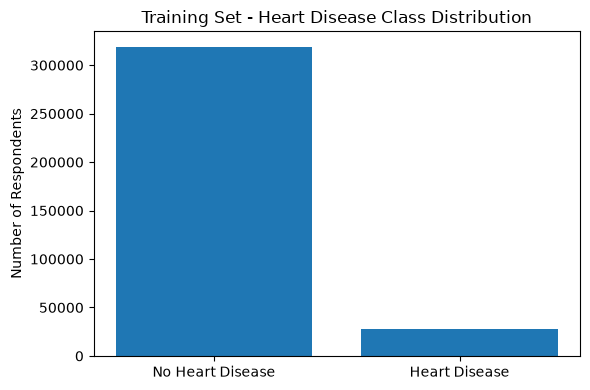

In [27]:
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    train_target_counts.values,
)

plt.title("Training Set - Heart Disease Class Distribution")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "01_target_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

The class imbalance explains why accuracy alone can be misleading.  
A model could predict the majority class almost every time and still report a high accuracy.

### 5.3 Missing Values in the Training Set

In [28]:
eda_missing = pd.DataFrame({
    "missing_count": train_df.isna().sum(),
    "missing_pct": (
        train_df.isna().mean() * 100
    ).round(2),
})

eda_missing = eda_missing.sort_values(
    "missing_pct",
    ascending=False,
)

display(eda_missing.head(15))

,missing_count,missing_pct
_INCOMG1,74115,21.34
TOLDHI3,50408,14.52
_RFCHOL3,50408,14.52
_VEGLT1A,47200,13.59
_FRTLT1A,40155,11.56
_BMI5,36816,10.60
_BMI5CAT,36816,10.60
_RFBING5,27721,7.98
_RFDRHV7,27458,7.91
DRNKANY5,24010,6.91


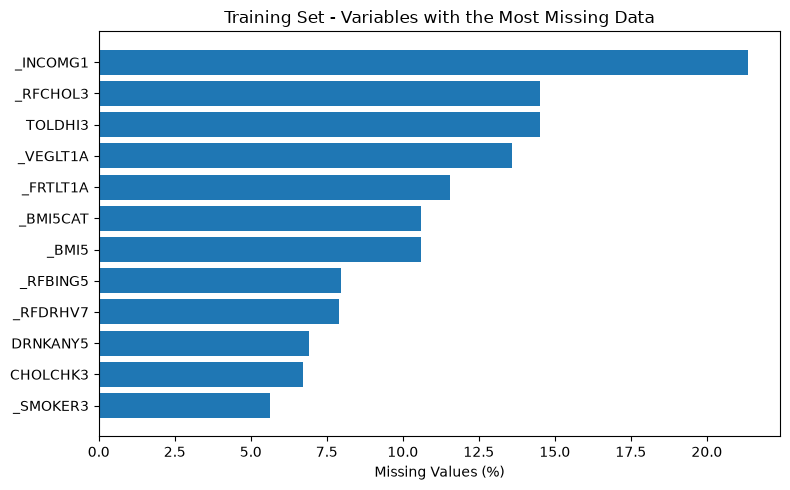

In [29]:
top_missing = (
    eda_missing[eda_missing["missing_pct"] > 0]
    .head(12)
    .sort_values("missing_pct")
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_missing.index,
    top_missing["missing_pct"],
)

plt.title("Training Set - Variables with the Most Missing Data")
plt.xlabel("Missing Values (%)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_missingness.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [30]:
top_missing_columns = (
    eda_missing[eda_missing["missing_pct"] > 0]
    .head(8)
    .index
    .tolist()
)

missing_by_target = (
    train_df[top_missing_columns]
    .isna()
    .groupby(train_df["HeartDisease"])
    .mean()
    .T
    * 100
).round(2)

missing_by_target.columns = [
    "No Heart Disease (%)",
    "Heart Disease (%)",
]

display(missing_by_target)

,No Heart Disease (%),Heart Disease (%)
_INCOMG1,21.33,21.49
TOLDHI3,15.18,6.99
_RFCHOL3,15.18,6.99
_VEGLT1A,13.58,13.79
_FRTLT1A,11.61,11.07
_BMI5,10.87,7.58
_BMI5CAT,10.87,7.58
_RFBING5,8.09,6.75


Missing values are still left as missing.

The modeling pipeline will learn any imputation values from each training fold instead of filling them globally before cross-validation.

### 5.4 Numeric Variables

In [31]:
numeric_eda_columns = [
    "PHYSHLTH",
    "MENTHLTH",
    "_BMI5",
    "_AGE80",
]

numeric_summary = train_df[
    numeric_eda_columns
].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).T

display(numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
PHYSHLTH,339959.0,3.749961,8.299271,0.0,0.00,0.00,0.00,0.00,2.00,30.00,30.00,30.00
MENTHLTH,341191.0,4.082910,8.132650,0.0,0.00,0.00,0.00,0.00,4.00,30.00,30.00,30.00
_BMI5,310430.0,28.540434,6.521378,12.0,17.85,20.18,24.14,27.44,31.66,40.62,49.42,99.33
_AGE80,347246.0,54.622274,17.552339,18.0,19.00,23.00,41.00,57.00,69.00,80.00,80.00,80.00


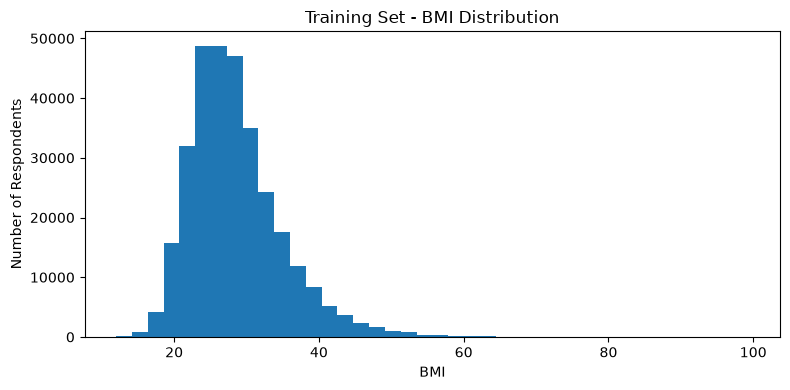

In [32]:
plt.figure(figsize=(8, 4))

plt.hist(
    train_df["_BMI5"].dropna(),
    bins=40,
)

plt.title("Training Set - BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_bmi_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [33]:
numeric_by_target = train_df.groupby(
    "HeartDisease"
)[numeric_eda_columns].agg([
    "mean",
    "median",
])

numeric_by_target.index = [
    "No Heart Disease",
    "Heart Disease",
]

display(numeric_by_target.round(2))

PHYSHLTH        MENTHLTH         _BMI5        _AGE80       
                     mean median     mean median   mean median   mean median
No Heart Disease     3.33    0.0     4.01    0.0  28.46  27.39  53.45   55.0
Heart Disease        8.61    1.0     4.90    0.0  29.42  28.34  67.85   70.0

### 5.5 Important Categorical Relationships

In [34]:
def target_rate_by_category(data, column, labels=None):
    result = (
        data.dropna(subset=[column])
        .groupby(column)["HeartDisease"]
        .agg(["count", "mean"])
        .reset_index()
        .sort_values(column)
    )

    result["heart_disease_pct"] = (
        result["mean"] * 100
    ).round(2)

    if labels is not None:
        result["label"] = result[column].map(labels)
    else:
        result["label"] = result[column].astype(str)

    return result[
        [
            column,
            "label",
            "count",
            "heart_disease_pct",
        ]
    ]

#### Age Group

In [35]:
AGE_LABELS = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80+",
}

age_target = target_rate_by_category(
    train_df,
    "_AGEG5YR",
    AGE_LABELS,
)

display(age_target)

,_AGEG5YR,label,count,heart_disease_pct
0,1.0,18-24,20654,0.60
1,2.0,25-29,17187,0.77
2,3.0,30-34,20471,1.14
3,4.0,35-39,22629,1.37
4,5.0,40-44,23415,2.26
5,6.0,45-49,22587,3.18
6,7.0,50-54,27222,4.92
7,8.0,55-59,30181,7.24
8,9.0,60-64,35214,9.27
9,10.0,65-69,36171,11.35


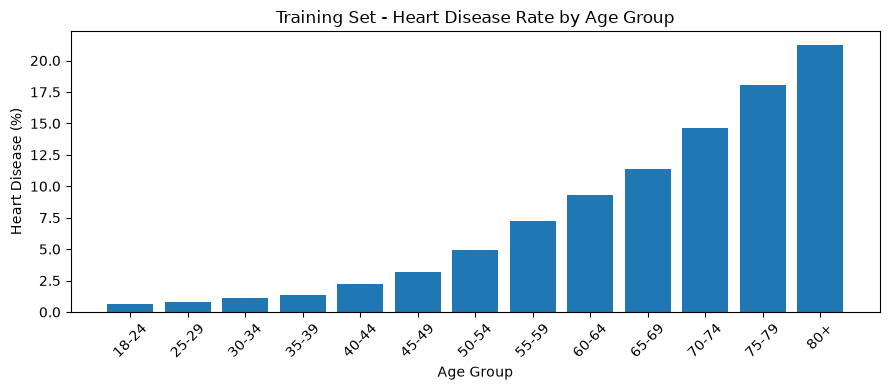

In [36]:
plt.figure(figsize=(9, 4))

plt.bar(
    age_target["label"],
    age_target["heart_disease_pct"],
)

plt.title("Training Set - Heart Disease Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Heart Disease (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_age_heart_disease_rate.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

#### General Health

In [37]:
GENERAL_HEALTH_LABELS = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor",
}

general_health_target = target_rate_by_category(
    train_df,
    "GENHLTH",
    GENERAL_HEALTH_LABELS,
)

display(general_health_target)

,GENHLTH,label,count,heart_disease_pct
0,1.0,Excellent,61944,2.02
1,2.0,Very good,118577,4.36
2,3.0,Good,109255,8.70
3,4.0,Fair,42753,18.42
4,5.0,Poor,13862,31.27


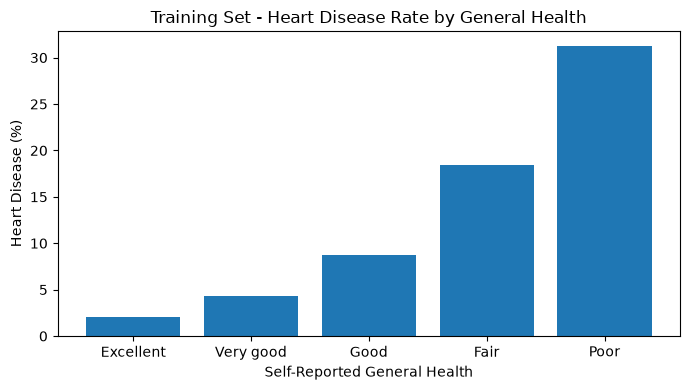

In [38]:
plt.figure(figsize=(7, 4))

plt.bar(
    general_health_target["label"],
    general_health_target["heart_disease_pct"],
)

plt.title("Training Set - Heart Disease Rate by General Health")
plt.xlabel("Self-Reported General Health")
plt.ylabel("Heart Disease (%)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "05_general_health_rate.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

#### Blood Pressure

In [39]:
BLOOD_PRESSURE_LABELS = {
    1: "High BP",
    2: "Pregnancy only",
    3: "No high BP",
    4: "Borderline",
}

blood_pressure_target = target_rate_by_category(
    train_df,
    "BPHIGH6",
    BLOOD_PRESSURE_LABELS,
)

display(blood_pressure_target)

,BPHIGH6,label,count,heart_disease_pct
0,1.0,High BP,135726,15.35
1,2.0,Pregnancy only,2741,3.14
2,3.0,No high BP,203851,3.45
3,4.0,Borderline,3625,5.46


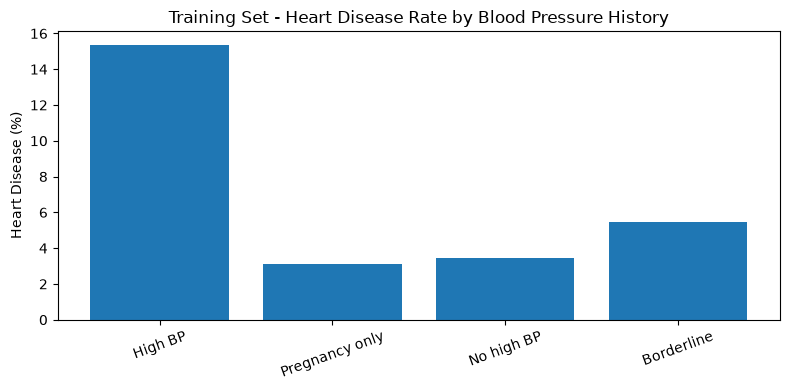

In [40]:
plt.figure(figsize=(8, 4))

plt.bar(
    blood_pressure_target["label"],
    blood_pressure_target["heart_disease_pct"],
)

plt.title("Training Set - Heart Disease Rate by Blood Pressure History")
plt.ylabel("Heart Disease (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_blood_pressure_rate.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

#### Diabetes

In [41]:
DIABETES_LABELS = {
    1: "Diabetes",
    2: "Pregnancy only",
    3: "No diabetes",
    4: "Prediabetes",
}

diabetes_target = target_rate_by_category(
    train_df,
    "DIABETE4",
    DIABETES_LABELS,
)

display(diabetes_target)

,DIABETE4,label,count,heart_disease_pct
0,1.0,Diabetes,45150,20.73
1,2.0,Pregnancy only,3022,3.84
2,3.0,No diabetes,290728,6.11
3,4.0,Prediabetes,7816,12.01


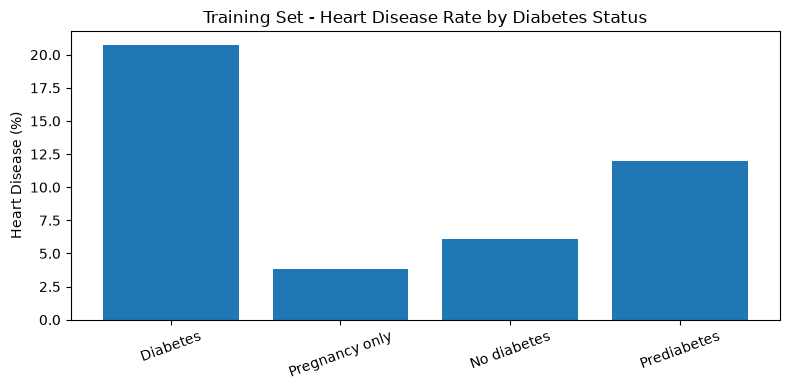

In [42]:
plt.figure(figsize=(8, 4))

plt.bar(
    diabetes_target["label"],
    diabetes_target["heart_disease_pct"],
)

plt.title("Training Set - Heart Disease Rate by Diabetes Status")
plt.ylabel("Heart Disease (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "07_diabetes_rate.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

#### Smoking Status

In [43]:
SMOKING_LABELS = {
    1: "Current - every day",
    2: "Current - some days",
    3: "Former smoker",
    4: "Never smoker",
}

smoking_target = target_rate_by_category(
    train_df,
    "_SMOKER3",
    SMOKING_LABELS,
)

display(smoking_target)

,_SMOKER3,label,count,heart_disease_pct
0,1.0,Current - every day,30788,10.75
1,2.0,Current - some days,11757,9.06
2,3.0,Former smoker,89647,12.53
3,4.0,Never smoker,195455,5.78


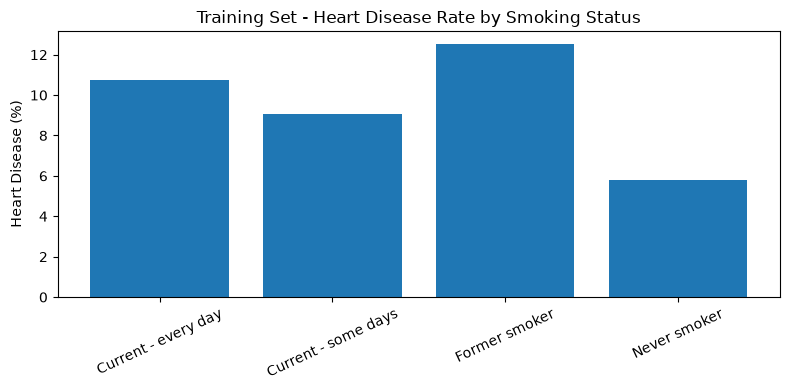

In [44]:
plt.figure(figsize=(8, 4))

plt.bar(
    smoking_target["label"],
    smoking_target["heart_disease_pct"],
)

plt.title("Training Set - Heart Disease Rate by Smoking Status")
plt.ylabel("Heart Disease (%)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "08_smoking_rate.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

The category comparisons are unadjusted associations from the training data.

They are useful for understanding the dataset, but they are not used as proof of causality and they do not decide the final feature set.

### 5.6 Correlation Analysis

Most BRFSS variables are categorical codes, so a Pearson correlation matrix across all columns would be misleading.

I restrict the matrix to variables with meaningful numeric ordering and use Spearman correlation.

In [45]:
correlation_columns = [
    "HeartDisease",
    "_AGE80",
    "_BMI5",
    "PHYSHLTH",
    "MENTHLTH",
]

spearman_corr = train_df[
    correlation_columns
].corr(method="spearman")

display(spearman_corr.round(3))

,HeartDisease,_AGE80,_BMI5,PHYSHLTH,MENTHLTH
HeartDisease,1.000,0.232,0.048,0.143,0.001
_AGE80,0.232,1.000,-0.005,0.050,-0.243
_BMI5,0.048,-0.005,1.000,0.099,0.033
PHYSHLTH,0.143,0.050,0.099,1.000,0.303
MENTHLTH,0.001,-0.243,0.033,0.303,1.000


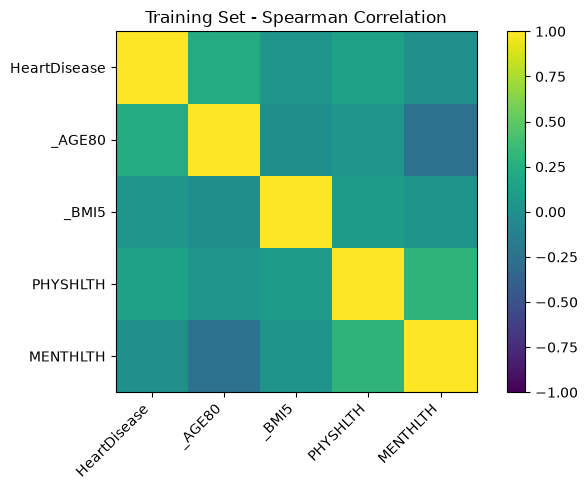

In [46]:
plt.figure(figsize=(7, 5))

image = plt.imshow(
    spearman_corr,
    vmin=-1,
    vmax=1,
)

plt.colorbar(image)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns,
)

plt.title("Training Set - Spearman Correlation")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "09_numeric_spearman_correlation.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 5.7 Key EDA Findings

In [47]:
def get_rate(table, raw_value):
    return float(
        table.loc[
            table.iloc[:, 0] == raw_value,
            "heart_disease_pct",
        ].iloc[0]
    )


top_missing_variable = eda_missing.index[0]
top_missing_pct = eda_missing.iloc[0]["missing_pct"]

eda_findings = pd.DataFrame({
    "finding": [
        "Training positive prevalence",
        "Majority-class accuracy",
        "Highest training missingness",
        "Heart disease rate - age 18-24",
        "Heart disease rate - age 80+",
        "Heart disease rate - excellent health",
        "Heart disease rate - poor health",
        "Heart disease rate - high blood pressure",
        "Heart disease rate - no high blood pressure",
        "Heart disease rate - diabetes",
        "Heart disease rate - no diabetes",
        "Heart disease rate - current daily smoker",
        "Heart disease rate - never smoker",
    ],
    "value": [
        f"{train_target_pct.loc[1]:.2f}%",
        f"{majority_accuracy:.2f}%",
        f"{top_missing_variable}: {top_missing_pct:.2f}%",
        f"{get_rate(age_target, 1):.2f}%",
        f"{get_rate(age_target, 13):.2f}%",
        f"{get_rate(general_health_target, 1):.2f}%",
        f"{get_rate(general_health_target, 5):.2f}%",
        f"{get_rate(blood_pressure_target, 1):.2f}%",
        f"{get_rate(blood_pressure_target, 3):.2f}%",
        f"{get_rate(diabetes_target, 1):.2f}%",
        f"{get_rate(diabetes_target, 3):.2f}%",
        f"{get_rate(smoking_target, 1):.2f}%",
        f"{get_rate(smoking_target, 4):.2f}%",
    ],
})

display(eda_findings)

,finding,value
0,Training positive prevalence,8.14%
1,Majority-class accuracy,91.86%
2,Highest training missingness,_INCOMG1: 21.34%
3,Heart disease rate - age 18-24,0.60%
4,Heart disease rate - age 80+,21.26%
5,Heart disease rate - excellent health,2.02%
6,Heart disease rate - poor health,31.27%
7,Heart disease rate - high blood pressure,15.35%
8,Heart disease rate - no high blood pressure,3.45%
9,Heart disease rate - diabetes,20.73%


### 5.8 Phase 5 Final Check

In [48]:
assert len(train_df) == 347246
assert len(test_df) == 86812
assert set(train_df.index).isdisjoint(test_df.index)
assert len(train_df) + len(test_df) == len(clean_df)
assert set(clean_df.columns).isdisjoint(
    DIRECT_LEAKAGE_COLUMNS
)
assert len(eda_findings) == 13
assert len(list(FIGURES_DIR.glob("*.png"))) >= 9

print("Phase 5: PASSED")
print("Frozen test set has not been used for model performance.")

Phase 5: PASSED
Frozen test set has not been used for model performance.


## Phase 5 Summary

The EDA was performed on the training set after freezing the holdout.

Main points carried into modeling:

- the target is strongly imbalanced,
- meaningful predictor missingness remains,
- categorical codes should not be treated as continuous numbers automatically,
- important health indicators show different unadjusted target rates,
- EDA is descriptive and does not select the final model or final feature set.

The next step is the supervised baseline.

## 6. Supervised Baseline and Preprocessing Pipeline

The baseline model is Logistic Regression.

The goal is not to optimize performance yet. The goal is to create a correct, reproducible starting point using:

- the frozen training set,
- the 28 primary candidate features,
- preprocessing inside a Scikit-learn Pipeline,
- stratified cross-validation,
- multiple metrics suitable for the imbalanced target.

The frozen test set is still not used for model performance.

### 6.1 Define the Modeling Data

In [49]:
X_train = train_df[PRIMARY_FEATURES].copy()
y_train = train_df["HeartDisease"].copy()

X_test = test_df[PRIMARY_FEATURES].copy()
y_test = test_df["HeartDisease"].copy()

assert X_train.shape == (347246, 28)
assert X_test.shape == (86812, 28)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Training positives:", f"{y_train.sum():,}")
print("Frozen test rows:", f"{len(y_test):,}")

X_train: (347246, 28)
X_test: (86812, 28)
Training positives: 28,258
Frozen test rows: 86,812


Only the primary candidate set is used for the baseline.

The sensitivity variables and alternative representations are intentionally excluded here. They will be tested later with the same cross-validation methodology.

### 6.2 Define Numeric and Categorical Features

In [50]:
NUMERIC_FEATURES = [
    "PHYSHLTH",
    "MENTHLTH",
    "_BMI5",
]

CATEGORICAL_FEATURES = [
    column
    for column in PRIMARY_FEATURES
    if column not in NUMERIC_FEATURES
]

assert len(NUMERIC_FEATURES) == 3
assert len(CATEGORICAL_FEATURES) == 25
assert set(NUMERIC_FEATURES + CATEGORICAL_FEATURES) == set(PRIMARY_FEATURES)

print("Numeric features:", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))

Numeric features: 3
Categorical features: 25


The BRFSS category numbers are labels, not continuous measurements.

For example, insurance type, marital status, smoking status, and blood-pressure categories should not be interpreted by Logistic Regression as if the difference between code 1 and code 2 were a numeric distance.

That is why these variables are encoded as categorical features.

### 6.3 Build the Preprocessing Pipeline

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value=-1,
        ),
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
        ),
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        NUMERIC_FEATURES,
    ),
    (
        "categorical",
        categorical_pipeline,
        CATEGORICAL_FEATURES,
    ),
])

baseline_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor,
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
        ),
    ),
])

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

All learned preprocessing is inside the Pipeline.

This prevents the median values, scaling parameters, and categorical encoding from being learned from validation folds or from the test set.

For categorical missing values I use a separate `-1` category instead of replacing them with the most common response. This preserves the fact that the survey response was missing.

### 6.4 Training Cross-Validation

In [52]:
from sklearn.metrics import (
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)

CV_SPLITS = 3

cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0,
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

baseline_cv_summary = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
    ],
    "mean": [
        baseline_cv["test_accuracy"].mean(),
        baseline_cv["test_precision"].mean(),
        baseline_cv["test_recall"].mean(),
        baseline_cv["test_f1"].mean(),
        baseline_cv["test_roc_auc"].mean(),
        baseline_cv["test_pr_auc"].mean(),
    ],
    "std": [
        baseline_cv["test_accuracy"].std(),
        baseline_cv["test_precision"].std(),
        baseline_cv["test_recall"].std(),
        baseline_cv["test_f1"].std(),
        baseline_cv["test_roc_auc"].std(),
        baseline_cv["test_pr_auc"].std(),
    ],
})

display(
    baseline_cv_summary.round(4)
)

,metric,mean,std
0,Accuracy,0.9201,0.0001
1,Precision,0.5480,0.0043
2,Recall,0.1032,0.0006
3,F1,0.1737,0.0009
4,ROC-AUC,0.8507,0.0009
5,PR-AUC,0.3477,0.0023


I use 3-fold stratified cross-validation for the baseline because the dataset is large.

With more than 300,000 training rows, 3 folds already provide large validation samples while reducing repeated training time and memory pressure on the laptop.

The same cross-validation setup should be reused when comparing models so the comparison is fair.

### 6.5 Fit the Baseline on the Full Training Set

In [53]:
baseline_pipeline.fit(
    X_train,
    y_train,
)

print("Baseline pipeline fitted on training data.")
print("The frozen test set has not been scored.")

Baseline pipeline fitted on training data.
The frozen test set has not been scored.


### 6.6 Save the Baseline CV Results

In [54]:
METRICS_DIR = Path("../outputs/metrics")
METRICS_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_CV_PATH = (
    METRICS_DIR
    / "phase06_logistic_baseline_cv.csv"
)

baseline_cv_summary.to_csv(
    BASELINE_CV_PATH,
    index=False,
)

print("Saved:", BASELINE_CV_PATH.resolve())

Saved: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\outputs\metrics\phase06_logistic_baseline_cv.csv


### 6.7 Phase 6 Final Check

In [55]:
assert len(baseline_cv_summary) == 6
assert baseline_cv_summary["mean"].between(
    0,
    1,
).all()

assert set(X_train.columns).isdisjoint(
    DIRECT_LEAKAGE_COLUMNS
)

assert baseline_pipeline.named_steps[
    "model"
].classes_.tolist() == [0, 1]

assert BASELINE_CV_PATH.exists()

print("Phase 6: PASSED")
print("Test-set model metrics calculated: No")
print("Next: Phase 7 - model comparison and imbalance experiments")

Phase 6: PASSED
Test-set model metrics calculated: No
Next: Phase 7 - model comparison and imbalance experiments


## Phase 6 Summary

The supervised baseline now has a leakage-safe structure:

```text
frozen training data
→ fold-specific imputation
→ scaling / one-hot encoding
→ Logistic Regression
→ stratified cross-validation
```

The test set is still reserved for the final evaluation.

The next phase will compare the baseline with at least one additional Scikit-learn classifier and evaluate imbalance strategies using the same training-only methodology.

## 7. Model Comparison and Class Imbalance

The baseline from the previous phase is Logistic Regression without class weighting.

In this phase I compare:

1. Logistic Regression baseline,
2. Logistic Regression with `class_weight="balanced"`,
3. Random Forest as a tree-based comparison model.

All models use the **same training data and the same 3-fold stratified cross-validation**.

The frozen test set is still not used for model performance.

### 7.1 Build the Comparison Models

In [56]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

weighted_logistic_pipeline = clone(
    baseline_pipeline
)

weighted_logistic_pipeline.set_params(
    model__class_weight="balanced"
)

random_forest_pipeline = Pipeline([
    (
        "preprocess",
        clone(preprocessor),
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=80,
            max_depth=14,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

print("Comparison models ready:")
print("- Logistic Regression (baseline)")
print("- Logistic Regression (balanced)")
print("- Random Forest")

Comparison models ready:
- Logistic Regression (baseline)
- Logistic Regression (balanced)
- Random Forest


The Random Forest settings are intentionally moderate.

The dataset contains more than 300,000 training rows, so this phase is a **model-family comparison**, not a large hyperparameter search.  
Deeper tuning is deferred until there is evidence that a model family is worth tuning.

### 7.2 Evaluate All Models with the Same Cross-Validation

In [57]:
def evaluate_model_cv(
    name,
    pipeline,
    X,
    y,
):
    results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    return {
        "model": name,
        "Accuracy": results["test_accuracy"].mean(),
        "Precision": results["test_precision"].mean(),
        "Recall": results["test_recall"].mean(),
        "F1": results["test_f1"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean(),
        "PR-AUC": results["test_pr_auc"].mean(),
    }


comparison_rows = []

# Reuse the Phase 6 baseline CV result instead of fitting it again.
baseline_row = {
    "model": "Logistic Regression",
    "Accuracy": baseline_cv_summary.loc[
        baseline_cv_summary["metric"] == "Accuracy",
        "mean",
    ].iloc[0],
    "Precision": baseline_cv_summary.loc[
        baseline_cv_summary["metric"] == "Precision",
        "mean",
    ].iloc[0],
    "Recall": baseline_cv_summary.loc[
        baseline_cv_summary["metric"] == "Recall",
        "mean",
    ].iloc[0],
    "F1": baseline_cv_summary.loc[
        baseline_cv_summary["metric"] == "F1",
        "mean",
    ].iloc[0],
    "ROC-AUC": baseline_cv_summary.loc[
        baseline_cv_summary["metric"] == "ROC-AUC",
        "mean",
    ].iloc[0],
    "PR-AUC": baseline_cv_summary.loc[
        baseline_cv_summary["metric"] == "PR-AUC",
        "mean",
    ].iloc[0],
}

comparison_rows.append(
    baseline_row
)

comparison_rows.append(
    evaluate_model_cv(
        "Logistic Regression - Balanced",
        weighted_logistic_pipeline,
        X_train,
        y_train,
    )
)

comparison_rows.append(
    evaluate_model_cv(
        "Random Forest",
        random_forest_pipeline,
        X_train,
        y_train,
    )
)

model_comparison = pd.DataFrame(
    comparison_rows
)

display(
    model_comparison.round(4)
)

,model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9201,0.5480,0.1032,0.1737,0.8507,0.3477
1,Logistic Regression - Balanced,0.7529,0.2199,0.7994,0.3449,0.8508,0.3459
2,Random Forest,0.9194,0.6512,0.0194,0.0377,0.8472,0.3422


The main goal is not to select the model with the highest accuracy.

Because the positive class is uncommon, I compare the models using:

- Precision,
- Recall,
- F1,
- ROC-AUC,
- PR-AUC.

`PR-AUC` is especially useful here because it focuses on performance for the positive class under imbalance.

### 7.3 Compare the Main Metrics

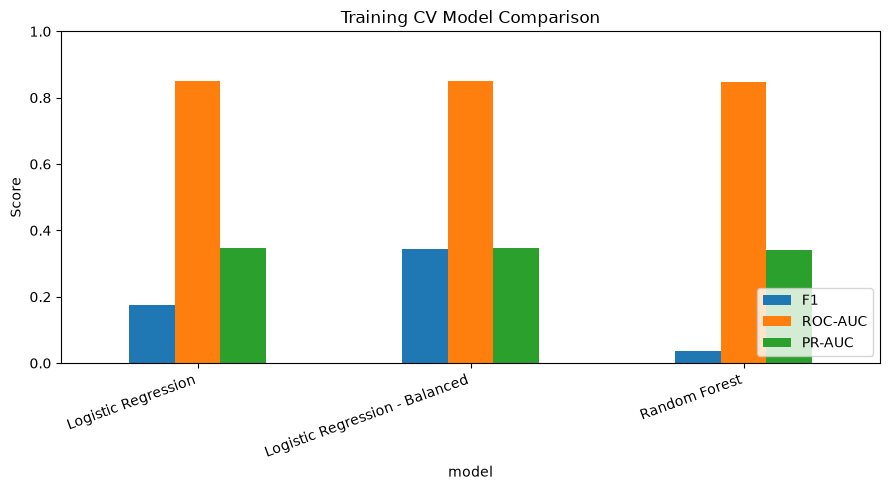

In [58]:
comparison_plot = (
    model_comparison
    .set_index("model")[
        [
            "F1",
            "ROC-AUC",
            "PR-AUC",
        ]
    ]
)

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Training CV Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "10_model_comparison_cv.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 7.4 Select a Provisional Model Using Training CV

In [59]:
model_comparison = model_comparison.sort_values(
    by=["PR-AUC", "F1"],
    ascending=False,
).reset_index(drop=True)

selected_model_name = model_comparison.loc[
    0,
    "model",
]

print(
    "Provisional model selected from training CV:",
    selected_model_name,
)

display(
    model_comparison.round(4)
)

Provisional model selected from training CV: Logistic Regression


,model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9201,0.5480,0.1032,0.1737,0.8507,0.3477
1,Logistic Regression - Balanced,0.7529,0.2199,0.7994,0.3449,0.8508,0.3459
2,Random Forest,0.9194,0.6512,0.0194,0.0377,0.8472,0.3422


The provisional model is selected using **PR-AUC first and F1 second**.

This is not the final project model yet.  
Phase 8 still needs to test feature representations, sensitivity features, and threshold behavior before the final model is frozen.

In [60]:
MODEL_PIPELINES = {
    "Logistic Regression": baseline_pipeline,
    "Logistic Regression - Balanced": weighted_logistic_pipeline,
    "Random Forest": random_forest_pipeline,
}

selected_pipeline = clone(
    MODEL_PIPELINES[selected_model_name]
)

print(
    "Selected pipeline:",
    selected_model_name,
)

Selected pipeline: Logistic Regression


### 7.5 Out-of-Fold Confusion Matrix

The confusion matrix is created from **out-of-fold predictions on the training set**.

Each row is predicted by a model that did not train on that row.  
This gives a more honest training-side diagnostic than fitting once and predicting the same training data.

In [61]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_predict

oof_predictions = cross_val_predict(
    selected_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict",
    n_jobs=1,
)

oof_confusion = confusion_matrix(
    y_train,
    oof_predictions,
)

display(
    pd.DataFrame(
        oof_confusion,
        index=[
            "Actual 0",
            "Actual 1",
        ],
        columns=[
            "Predicted 0",
            "Predicted 1",
        ],
    )
)

,Predicted 0,Predicted 1
Actual 0,316582,2406
Actual 1,25341,2917


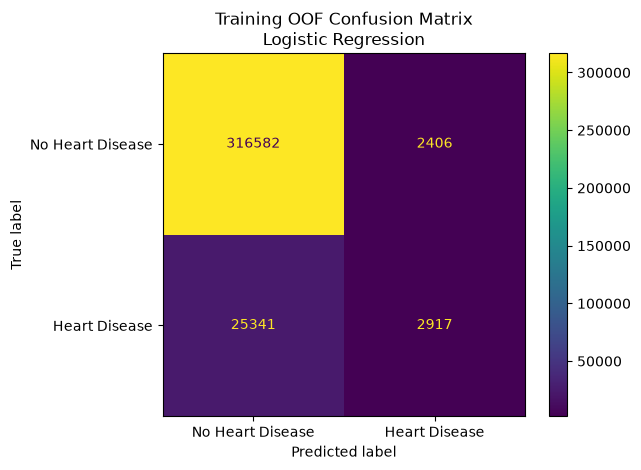

In [62]:
ConfusionMatrixDisplay(
    confusion_matrix=oof_confusion,
    display_labels=[
        "No Heart Disease",
        "Heart Disease",
    ],
).plot()

plt.title(
    f"Training OOF Confusion Matrix\n{selected_model_name}"
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "11_training_oof_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [63]:
print(
    classification_report(
        y_train,
        oof_predictions,
        target_names=[
            "No Heart Disease",
            "Heart Disease",
        ],
        digits=3,
        zero_division=0,
    )
)

                  precision    recall  f1-score   support

No Heart Disease      0.926     0.992     0.958    318988
   Heart Disease      0.548     0.103     0.174     28258

        accuracy                          0.920    347246
       macro avg      0.737     0.548     0.566    347246
    weighted avg      0.895     0.920     0.894    347246



For this project:

- a **false positive** means the model predicts heart-disease status for a respondent whose BRFSS target is negative;
- a **false negative** means the model predicts no heart-disease status for a respondent whose BRFSS target is positive.

This is still a survey classification task, so these errors should not be described as clinical diagnoses or treatment decisions.

### 7.6 Fit the Provisional Model on the Full Training Set

In [64]:
selected_pipeline.fit(
    X_train,
    y_train,
)

print(
    "Provisional model fitted on the full training set:",
    selected_model_name,
)

print("Frozen test set scored: No")

Provisional model fitted on the full training set: Logistic Regression
Frozen test set scored: No


### 7.7 Save the Phase 7 Results

In [65]:
MODEL_COMPARISON_PATH = (
    METRICS_DIR
    / "phase07_model_comparison_cv.csv"
)

model_comparison.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
)

print(
    "Saved:",
    MODEL_COMPARISON_PATH.resolve(),
)

Saved: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\outputs\metrics\phase07_model_comparison_cv.csv


### 7.8 Phase 7 Final Check

In [66]:
assert len(model_comparison) == 3

assert model_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
    ]
].apply(
    lambda column: column.between(0, 1).all()
).all()

assert oof_confusion.sum() == len(y_train)

assert set(X_train.columns).isdisjoint(
    DIRECT_LEAKAGE_COLUMNS
)

assert MODEL_COMPARISON_PATH.exists()

print("Phase 7: PASSED")
print("Test-set model metrics calculated: No")
print("Next: Phase 8 - feature ablation, tuning, and threshold selection")

Phase 7: PASSED
Test-set model metrics calculated: No
Next: Phase 8 - feature ablation, tuning, and threshold selection


## Phase 7 Summary

The project now has:

- a Logistic Regression baseline,
- an imbalance-aware Logistic Regression,
- a tree-based comparison model,
- identical stratified cross-validation,
- Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC,
- an out-of-fold training confusion matrix,
- a provisional model selected without using the test set.

The next phase will test feature representations and sensitivity features before any final test evaluation.